# EEG-Based Alzheimer's Disease Classification

### Pilot Analysis — MNE-Python & Machine Learning

This project develops a reproducible EEG preprocessing and spectral feature-extraction pipeline for Alzheimer's disease research using resting-state, eyes-closed EEG.

**Pilot subject:** `sub-001`  
**Dataset:** OpenNeuro `ds004504`

In [1]:
print("Alzheimer's EEG Project")

Alzheimer's EEG Project


In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt

In [3]:
print("MNE version:", mne.__version__)
print("NumPy version:", np.__version__)

MNE version: 1.13.2
NumPy version: 2.5.3


In [4]:
import sys

print("Python version:", sys.version)
print("Python location:", sys.executable)

Python version: 3.12.14 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:37:13) [MSC v.1942 64 bit (AMD64)]
Python location: C:\Users\Saunak Das\miniconda3\envs\alzheimer_eeg\python.exe


In [5]:
from pathlib import Path

In [6]:
data_path = Path("../data")

In [7]:
print(data_path.exists())

True


In [8]:
for item in data_path.iterdir():
    print(item.name)

.datalad
.gitattributes
CHANGES
dataset_description.json
derivatives
participants.json
participants.tsv
README
sub-001
sub-001_pilot_features.csv
sub-002
sub-003
sub-004
sub-005
sub-006
sub-007
sub-008
sub-009
sub-010
sub-011
sub-012
sub-013
sub-014
sub-015
sub-016
sub-017
sub-018
sub-019
sub-020
sub-021
sub-022
sub-023
sub-024
sub-025
sub-026
sub-027
sub-028
sub-029
sub-030
sub-031
sub-032
sub-033
sub-034
sub-035
sub-036
sub-037
sub-038
sub-039
sub-040
sub-041
sub-042
sub-043
sub-044
sub-045
sub-046
sub-047
sub-048
sub-049
sub-050
sub-051
sub-052
sub-053
sub-054
sub-055
sub-056
sub-057
sub-058
sub-059
sub-060
sub-061
sub-062
sub-063
sub-064
sub-065
sub-066
sub-067
sub-068
sub-069
sub-070
sub-071
sub-072
sub-073
sub-074
sub-075
sub-076
sub-077
sub-078
sub-079
sub-080
sub-081
sub-082
sub-083
sub-084
sub-085
sub-086
sub-087
sub-088


In [9]:
import pandas as pd

In [10]:
participants = pd.read_csv(data_path / "participants.tsv", sep="\t")

In [11]:
participants.head()

,participant_id,Gender,Age,Group,MMSE
0,sub-001,F,57,A,16
1,sub-002,F,78,A,22
2,sub-003,M,70,A,14
3,sub-004,F,67,A,20
4,sub-005,M,70,A,22


In [12]:
participants.columns

Index(['participant_id', 'Gender', 'Age', 'Group', 'MMSE'], dtype='str')

In [13]:
participants["Group"].unique()

<StringArray>
['A', 'C', 'F']
Length: 3, dtype: str

In [14]:
participants["Group"].value_counts()

Group
A    36
C    29
F    23
Name: count, dtype: int64

In [15]:
subject_path = data_path / "sub-001"

In [16]:
for item in subject_path.iterdir():
    print(item.name)

eeg


In [17]:
eeg_path = subject_path / "eeg"

In [18]:
for item in eeg_path.iterdir():
    print(item.name)

sub-001_task-eyesclosed_channels.tsv
sub-001_task-eyesclosed_eeg.json
sub-001_task-eyesclosed_eeg.set


In [19]:
eeg_file = eeg_path / "sub-001_task-eyesclosed_eeg.set"

In [20]:
raw = mne.io.read_raw_eeglab(eeg_file, preload=False)

Reading C:\Users\Saunak Das\alzheimers-eeg-ml\notebooks\..\data\sub-001\eeg\sub-001_task-eyesclosed_eeg.set


In [21]:
print(raw)

<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~26 KiB, data not loaded>


In [22]:
print(raw.info["sfreq"])

500.0


In [23]:
print(raw.ch_names)

['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']


In [24]:
print(raw.info.keys())

dict_keys(['acq_pars', 'acq_stim', 'ctf_head_t', 'description', 'dev_head_t', 'dev_ctf_t', 'dig', 'experimenter', 'utc_offset', 'device_info', 'file_id', 'highpass', 'hpi_subsystem', 'kit_system_id', 'helium_info', 'line_freq', 'lowpass', 'meas_date', 'meas_id', 'proj_id', 'proj_name', 'subject_info', 'xplotter_layout', 'gantry_angle', 'bads', 'chs', 'comps', 'events', 'hpi_meas', 'hpi_results', 'projs', 'proc_history', 'custom_ref_applied', 'sfreq', 'ch_names', 'nchan'])


In [25]:
print(raw.info["nchan"])

19


In [26]:
print(raw.info["bads"])

[]


In [27]:
print("High-pass:", raw.info["highpass"])
print("Low-pass:", raw.info["lowpass"])

High-pass: 0.0
Low-pass: 250.0


In [28]:
print("Line frequency:", raw.info["line_freq"])

Line frequency: None


In [29]:
print(raw.info["meas_date"])

None


In [30]:
raw.get_data(start=0, stop=10).shape

(19, 10)

In [31]:
data = raw.get_data(start=0, stop=10)

In [32]:
print(data.shape)

(19, 10)


In [33]:
print(data)

[[-1.89892563e-04 -1.80419907e-04 -1.66992172e-04 -1.60205063e-04
  -1.59326157e-04 -1.54296860e-04 -1.71093735e-04 -1.83544907e-04
  -1.81542953e-04 -1.75927719e-04]
 [-1.41845688e-04 -1.37353500e-04 -1.35058578e-04 -1.32958969e-04
  -1.24462883e-04 -1.15820305e-04 -1.26074211e-04 -1.34326157e-04
  -1.36425766e-04 -1.33056625e-04]
 [-1.07373039e-04 -1.00048820e-04 -1.05761711e-04 -1.05322258e-04
  -1.04150383e-04 -9.73632736e-05 -1.04785149e-04 -1.16455070e-04
  -1.21972649e-04 -1.15576164e-04]
 [ 2.84667988e-05  3.22753906e-05  3.53515625e-05  3.80371094e-05
   4.11621094e-05  5.11718750e-05  4.57031212e-05  3.93066406e-05
   3.40820313e-05  3.92089844e-05]
 [-1.08447258e-04 -1.03369133e-04 -1.01953117e-04 -9.97558517e-05
  -9.84863205e-05 -8.97460937e-05 -9.71679611e-05 -1.04248039e-04
  -1.07617180e-04 -1.03955070e-04]
 [-3.64746094e-05 -3.36425781e-05 -2.98828125e-05 -2.70996075e-05
  -2.44628906e-05 -1.32812519e-05 -1.69921894e-05 -2.54394512e-05
  -3.12499981e-05 -2.50488262e-05

In [34]:
print(raw.get_montage())

<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 19 channels>


In [35]:
positions = raw.get_montage().get_positions()["ch_pos"]

In [36]:
print(type(positions))
print(len(positions))

<class 'collections.OrderedDict'>
19


In [37]:
print(positions["Fp1"])

[-0.0294367  0.0839171 -0.00699  ]


In [38]:
print(raw.get_montage().get_positions()["coord_frame"])

head


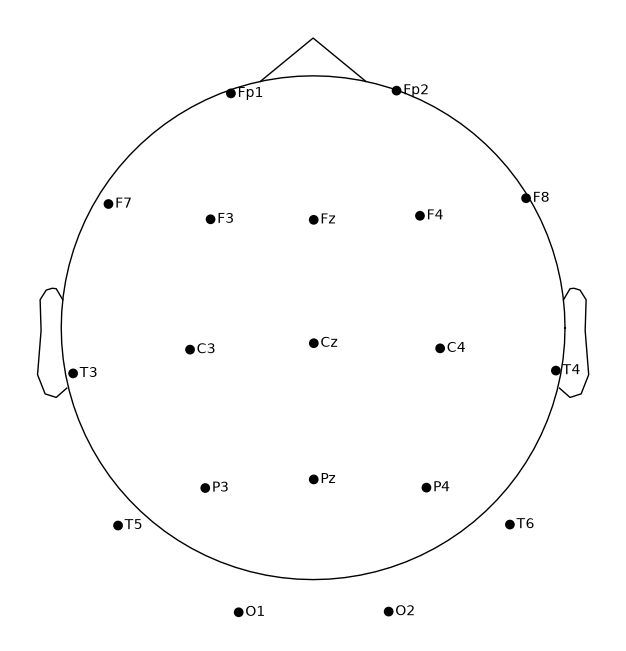

In [39]:
raw.get_montage().plot();

Using matplotlib as 2D backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


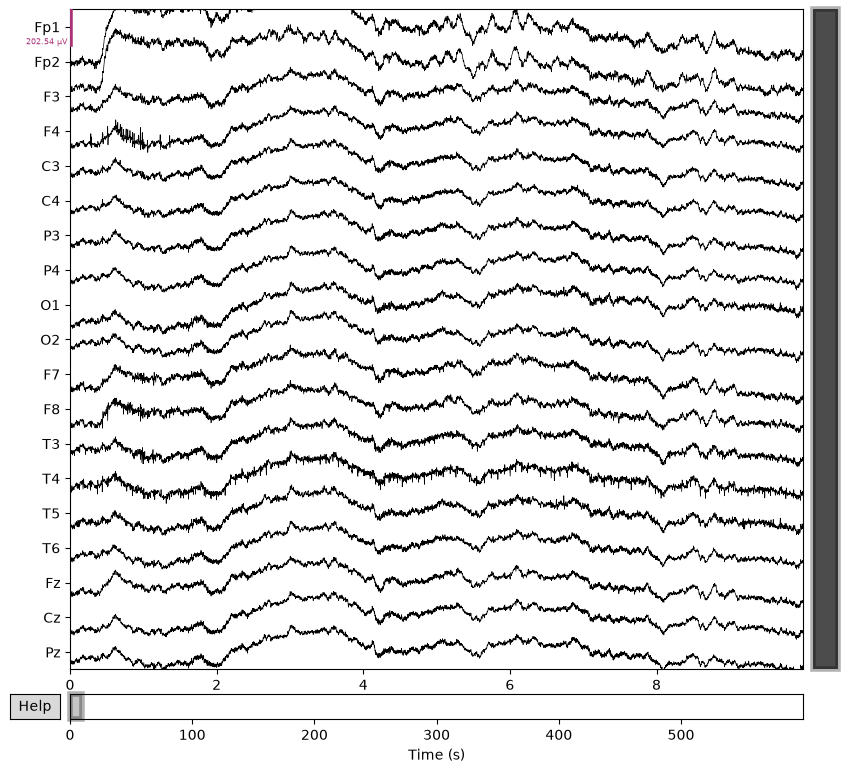

In [40]:
raw.plot(duration=10, n_channels=19, scalings="auto");

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


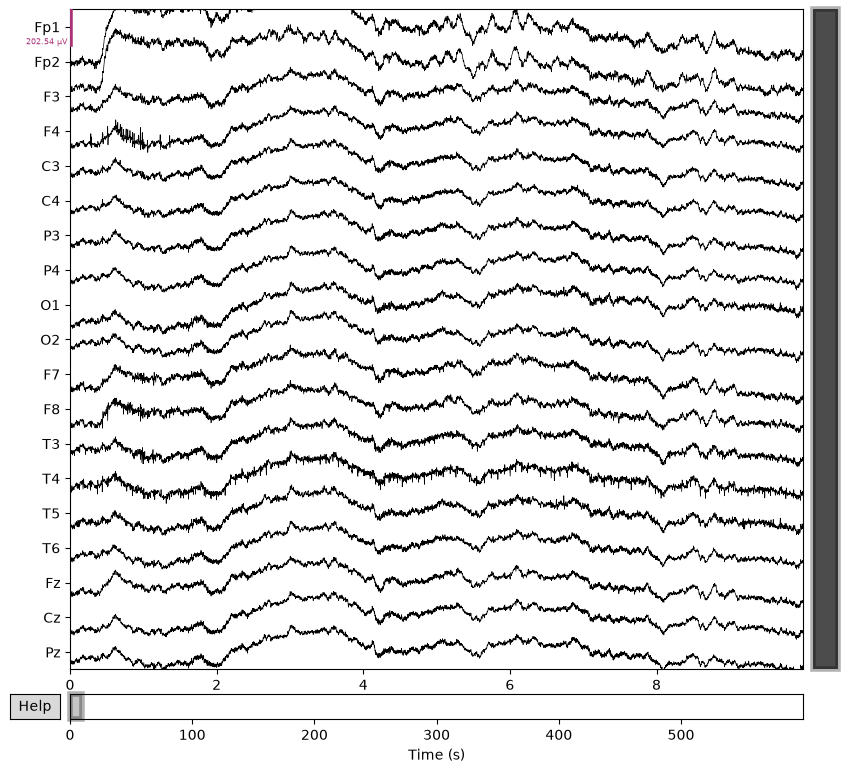

In [41]:
raw.plot(duration=10, n_channels=19, scalings="auto");

In [42]:
print(raw.get_channel_types())

['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg']


In [43]:
data = raw.get_data()
print("Minimum:", data.min())
print("Maximum:", data.max())

Minimum: -0.00046611325073242185
Maximum: 0.0028796384277343747


In [44]:
print("Mean:", data.mean())
print("Standard deviation:", data.std())

Mean: 3.3488209181823e-05
Standard deviation: 0.00011126369084712183


For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


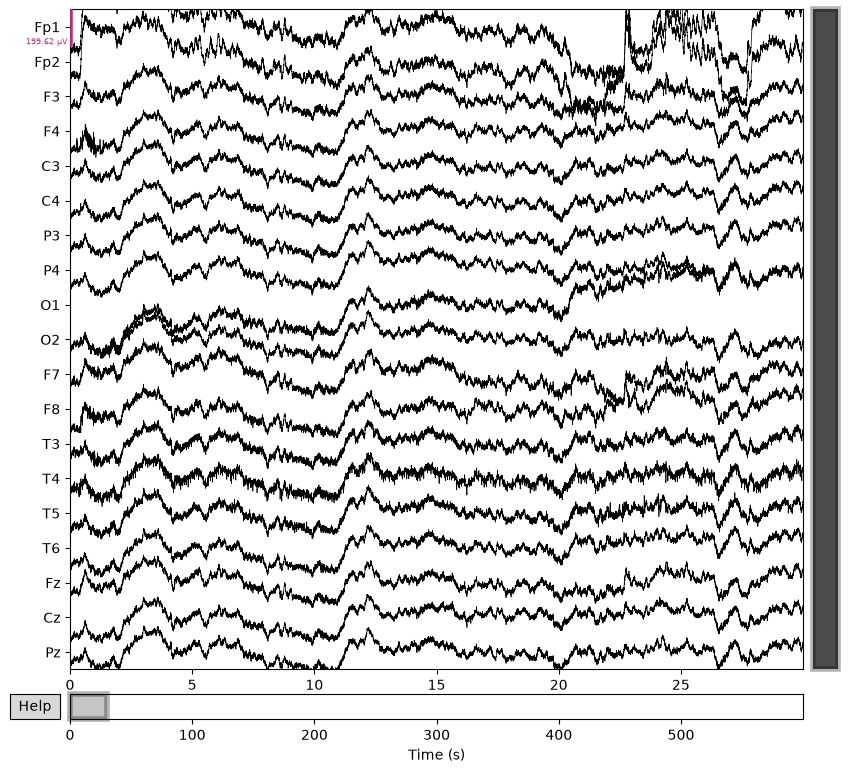

In [45]:
raw.plot(duration=30, n_channels=19, scalings="auto");

In [46]:
print(raw.info["custom_ref_applied"])

0 (FIFFV_MNE_CUSTOM_REF_OFF)


In [47]:
print(raw.info["chs"][0])

{'loc': array([-0.0294367,  0.0839171, -0.00699  ,  0.       ,  0.       ,
        0.       ,        nan,        nan,        nan,        nan,
              nan,        nan]), 'unit_mul': 0 (FIFF_UNITM_NONE), 'range': 1.0, 'cal': 1e-06, 'kind': 2 (FIFFV_EEG_CH), 'coil_type': 1 (FIFFV_COIL_EEG), 'unit': 107 (FIFF_UNIT_V), 'coord_frame': 4 (FIFFV_COORD_HEAD), 'ch_name': 'Fp1', 'scanno': 1, 'logno': 1}


In [48]:
print(raw.info["projs"])

[]


In [49]:
import json

with open(eeg_path / "sub-001_task-eyesclosed_eeg.json") as f:
    eeg_info = json.load(f)

print(eeg_info)

{'PowerLineFrequency': 50, 'SoftwareFilters': {'FilterDescription': {'Description': '0.4 - 50'}}, 'EEGPlacementScheme': '10-20', 'EEGReference': 'A1 A2', 'CapManufacturersModelName': 'EEG 2100', 'CapManufacturer': 'Nihon Kohden', 'InstitutionAddress': 'Arta, Greece', 'InstitutionalDepartmentName': 'Department of Informatics and Telecommunications', 'InstitutionName': 'University of Ioannina', 'TaskName': 'eyesclosed', 'EEGChannelCount': 19, 'RecordingType': 'continuous', 'RecordingDuration': 599.8, 'SamplingFrequency': 500, 'EOGChannelCount': 0, 'ECGChannelCount': 0, 'EMGChannelCount': 0}


In [50]:
raw_filtered = raw.copy()

In [51]:
raw_filtered.load_data()

Reading 0 ... 299899  =      0.000 ...   599.798 secs...


<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>

In [52]:
print(raw_filtered.preload)

True


Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


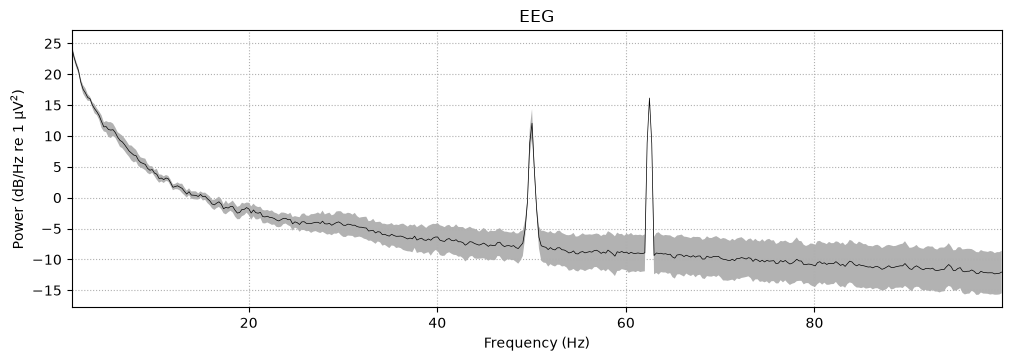

In [53]:
psd_1_100 = raw_filtered.compute_psd(
    method="welch",
    fmin=1,
    fmax=100
)

psd_1_100.plot(average=True);

Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


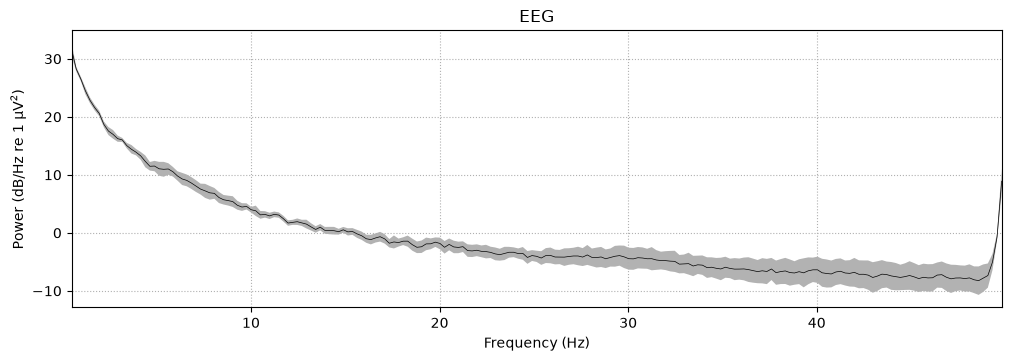

In [54]:
psd_04_50 = raw_filtered.compute_psd(
    method="welch",
    fmin=0.4,
    fmax=50
)

psd_04_50.plot(average=True);

In [55]:
print(psd_1_100.freqs[(psd_1_100.freqs >= 45) & (psd_1_100.freqs <= 55)])

[45.16601562 45.41015625 45.65429688 45.8984375  46.14257812 46.38671875
 46.63085938 46.875      47.11914062 47.36328125 47.60742188 47.8515625
 48.09570312 48.33984375 48.58398438 48.828125   49.07226562 49.31640625
 49.56054688 49.8046875  50.04882812 50.29296875 50.53710938 50.78125
 51.02539062 51.26953125 51.51367188 51.7578125  52.00195312 52.24609375
 52.49023438 52.734375   52.97851562 53.22265625 53.46679688 53.7109375
 53.95507812 54.19921875 54.44335938 54.6875     54.93164062]


In [56]:
idx = np.where((psd_1_100.freqs >= 45) & (psd_1_100.freqs <= 55))[0]

peak_idx = idx[np.argmax(psd_1_100.get_data()[:, idx].mean(axis=0))]

print("Peak frequency:", psd_1_100.freqs[peak_idx])

Peak frequency: 50.048828125


In [57]:
raw_notched = raw_filtered.copy()

In [58]:
raw_notched.notch_filter(freqs=50)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 3301 samples (6.602 s)



<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>

In [59]:
psd_notched = raw_notched.compute_psd(
    method="welch",
    fmin=1,
    fmax=100
)

Effective window size : 4.096 (s)


In [60]:
idx = np.where(
    (psd_notched.freqs >= 45) &
    (psd_notched.freqs <= 55)
)[0]

peak_idx = idx[
    np.argmax(
        psd_notched.get_data()[:, idx].mean(axis=0)
    )
]

print("Peak frequency after notch:", psd_notched.freqs[peak_idx])
print("Peak power after notch:", psd_notched.get_data()[:, peak_idx].mean())

Peak frequency after notch: 50.537109375
Peak power after notch: 3.4295237556505824e-13


Plotting power spectral density (dB=True).


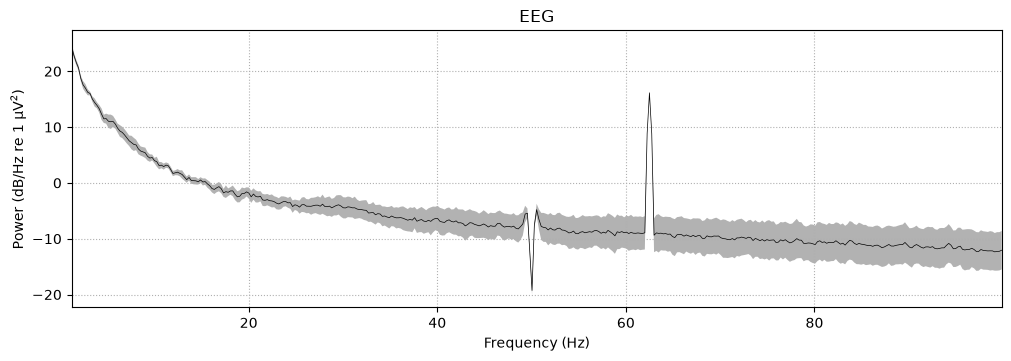

In [61]:
psd_notched.plot(average=True);

In [62]:
idx_60_65 = np.where(
    (psd_notched.freqs >= 60) &
    (psd_notched.freqs <= 65)
)[0]

peak_idx_60_65 = idx_60_65[
    np.argmax(
        psd_notched.get_data()[:, idx_60_65].mean(axis=0)
    )
]

print("Peak frequency:", psd_notched.freqs[peak_idx_60_65])
print("Peak power:", psd_notched.get_data()[:, peak_idx_60_65].mean())

Peak frequency: 62.5
Peak power: 4.1117979123098414e-11


In [63]:
channel_power_62_5 = psd_notched.get_data()[:, peak_idx_60_65]

for ch, power in zip(raw_notched.ch_names, channel_power_62_5):
    print(ch, power)

Fp1 4.151116822070693e-11
Fp2 4.1583456777521896e-11
F3 4.08215857768793e-11
F4 4.0914280315015044e-11
C3 4.082788456804955e-11
C4 4.088447958241726e-11
P3 4.0754431960025606e-11
P4 4.080760243666872e-11
O1 4.119667262603721e-11
O2 4.1006869544716946e-11
F7 4.247557183031068e-11
F8 4.1634308299330525e-11
T3 4.103842332492721e-11
T4 4.1353497794369415e-11
T5 4.083095110664248e-11
T6 4.086845651935078e-11
Fz 4.1116360699756136e-11
Cz 4.07702805385131e-11
Pz 4.0845321417631006e-11


In [64]:
print(psd_notched.freqs[peak_idx_60_65])

62.5


In [65]:
print(psd_notched.freqs[(psd_notched.freqs >= 60) & (psd_notched.freqs <= 65)])

[60.05859375 60.30273438 60.546875   60.79101562 61.03515625 61.27929688
 61.5234375  61.76757812 62.01171875 62.25585938 62.5        62.74414062
 62.98828125 63.23242188 63.4765625  63.72070312 63.96484375 64.20898438
 64.453125   64.69726562 64.94140625]


In [66]:
mask_60_65 = (psd_notched.freqs >= 60) & (psd_notched.freqs <= 65)

freqs_60_65 = psd_notched.freqs[mask_60_65]

power_60_65 = psd_notched.get_data()[:, mask_60_65].mean(axis=0)

for freq, power in zip(freqs_60_65, power_60_65):
    print(freq, power)

60.05859375 1.6363582689691668e-13
60.302734375 1.5801874947591088e-13
60.546875 1.6676966458829686e-13
60.791015625 1.556200082074794e-13
61.03515625 1.5631842813324965e-13
61.279296875 1.578517233618143e-13
61.5234375 1.5862831831103404e-13
61.767578125 1.5458971206181037e-13
62.01171875 1.5941956568803773e-13
62.255859375 7.671594517155e-12
62.5 4.1117979123098414e-11
62.744140625 7.63701768144816e-12
62.98828125 1.456471859104515e-13
63.232421875 1.6476445000058223e-13
63.4765625 1.6869985512483464e-13
63.720703125 1.602486265927412e-13
63.96484375 1.5334229577050388e-13
64.208984375 1.5544076793363164e-13
64.453125 1.528040673178411e-13
64.697265625 1.5269950815878085e-13
64.94140625 1.4264756960646564e-13


For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


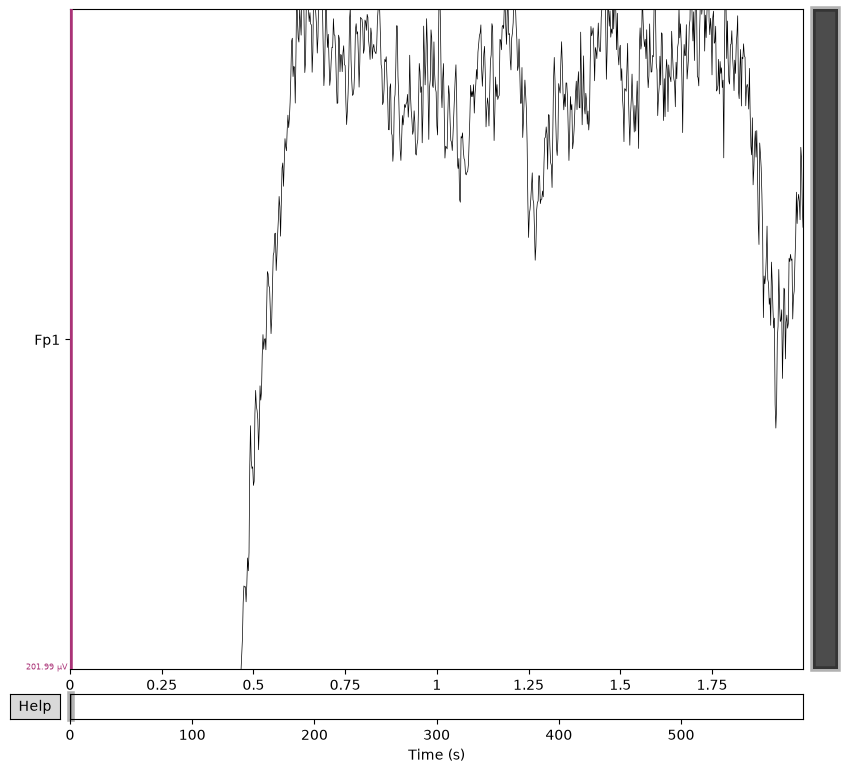

In [67]:
raw_notched.plot(
    picks="Fp1",
    duration=2,
    scalings="auto"
);

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


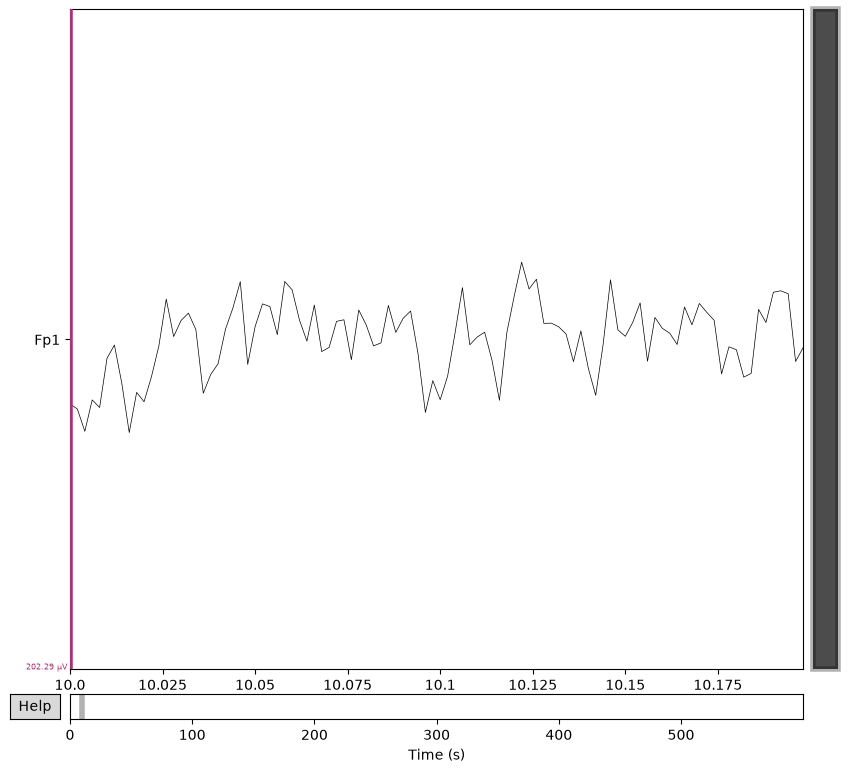

In [68]:
raw_notched.plot(
    picks="Fp1",
    start=10,
    duration=0.2,
    scalings="auto"
);

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 60 - 65 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 60.00
- Lower transition bandwidth: 15.00 Hz (-6 dB cutoff frequency: 52.50 Hz)
- Upper passband edge: 65.00 Hz
- Upper transition bandwidth: 16.25 Hz (-6 dB cutoff frequency: 73.12 Hz)
- Filter length: 111 samples (0.222 s)

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


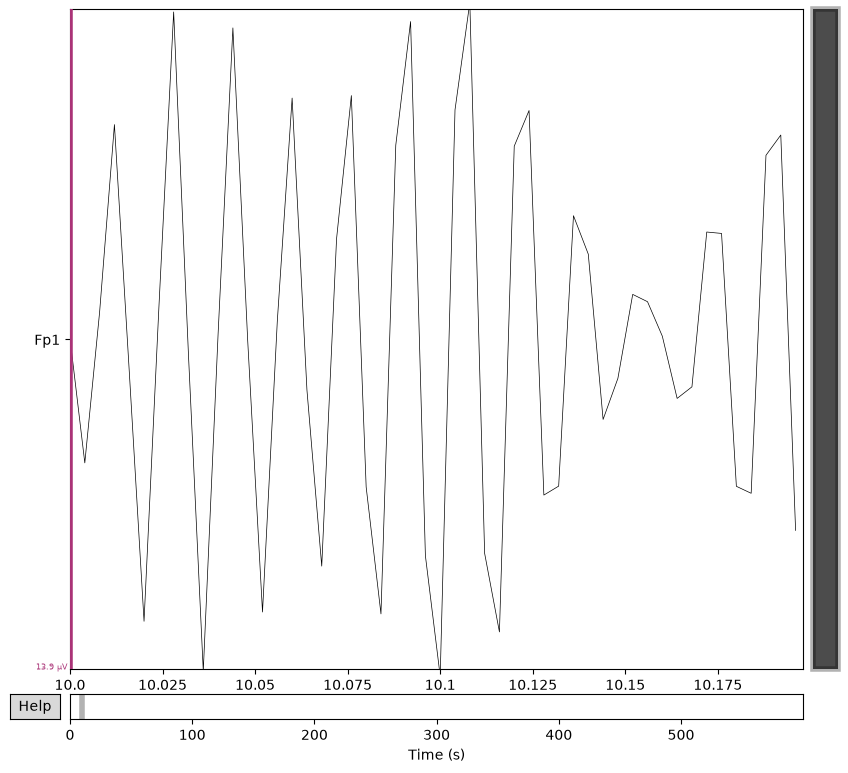

In [69]:
raw_62 = raw_notched.copy()

raw_62.filter(l_freq=60, h_freq=65)

raw_62.plot(
    picks="Fp1",
    start=10,
    duration=0.2,
    scalings="auto"
);

In [70]:
print(
    "62.5 Hz power before notch:",
    psd_1_100.get_data()[:, peak_idx_60_65].mean()
)

print(
    "62.5 Hz power after notch:",
    psd_notched.get_data()[:, peak_idx_60_65].mean()
)

62.5 Hz power before notch: 4.1135643486413095e-11
62.5 Hz power after notch: 4.1117979123098414e-11


In [71]:
epochs = mne.make_fixed_length_epochs(
    raw_notched,
    duration=4.0,
    overlap=0,
    preload=True
)

Not setting metadata
149 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 149 events and 2000 original time points ...
0 bad epochs dropped


In [72]:
print(epochs.get_data().shape)

(149, 19, 2000)


For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


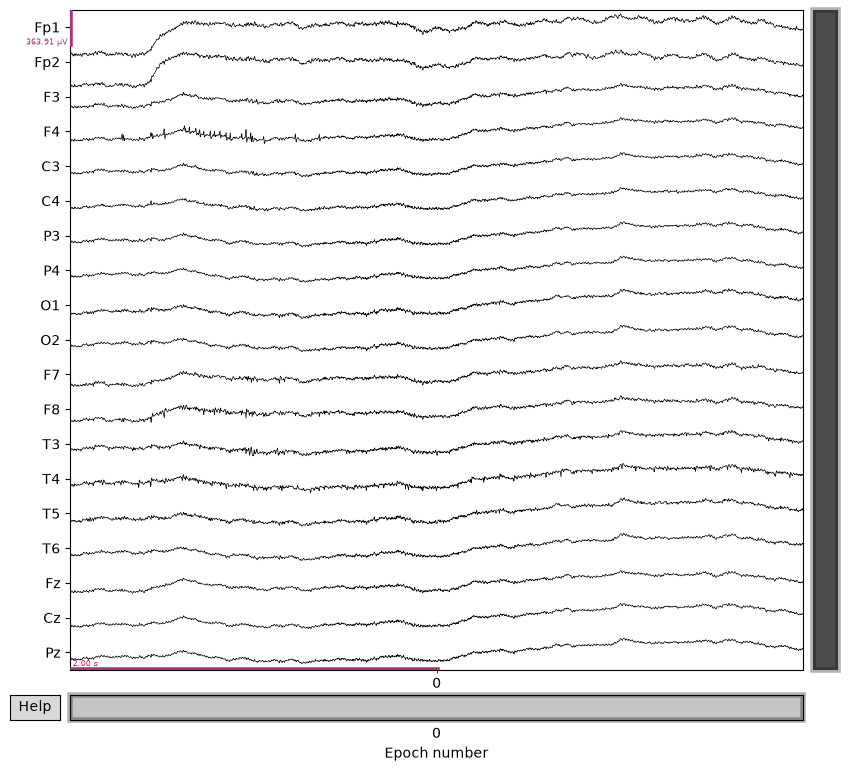

In [73]:
epochs[0].plot(n_channels=19, scalings="auto");

In [74]:
epochs_psd = epochs.compute_psd(
    method="welch",
    fmin=1,
    fmax=45
)

Effective window size : 4.000 (s)


In [75]:
print(epochs_psd.get_data().shape)

(149, 19, 177)


In [76]:
print(epochs_psd.freqs[:10])
print(epochs_psd.freqs[-10:])

[1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25]
[42.75 43.   43.25 43.5  43.75 44.   44.25 44.5  44.75 45.  ]


In [77]:
bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45)
}

In [78]:
alpha_mask = (
    (epochs_psd.freqs >= 8) &
    (epochs_psd.freqs < 13)
)

alpha_power = np.trapezoid(
    epochs_psd.get_data()[:, :, alpha_mask],
    x=epochs_psd.freqs[alpha_mask],
    axis=-1
)

In [79]:
print(alpha_power.shape)

(149, 19)


In [80]:
band_power = {}

psd_data = epochs_psd.get_data()
freqs = epochs_psd.freqs

for band, (fmin, fmax) in bands.items():
    mask = (freqs >= fmin) & (freqs <= fmax)
    
    band_power[band] = np.trapezoid(
        psd_data[:, :, mask],
        x=freqs[mask],
        axis=-1
    )

In [81]:
for band, power in band_power.items():
    print(band, power.shape)

delta (149, 19)
theta (149, 19)
alpha (149, 19)
beta (149, 19)
gamma (149, 19)


In [82]:
total_power = np.trapezoid(
    psd_data,
    x=freqs,
    axis=-1
)

In [83]:
relative_power = {}

for band, power in band_power.items():
    relative_power[band] = power / total_power

In [84]:
print(relative_power["alpha"].shape)
print(relative_power["alpha"][0])

(149, 19)
[0.03401258 0.03006455 0.02768289 0.02631472 0.02987124 0.02451515
 0.03086454 0.03056313 0.04133696 0.03358311 0.02566571 0.02737229
 0.03229704 0.02949101 0.04005333 0.03030929 0.02775148 0.02771623
 0.02733577]


In [85]:
print(
    relative_power["delta"][0, 0]
    + relative_power["theta"][0, 0]
    + relative_power["alpha"][0, 0]
    + relative_power["beta"][0, 0]
    + relative_power["gamma"][0, 0]
)

1.0


In [86]:
for band in relative_power:
    print(band, relative_power[band][0, 0])

delta 0.7242929763543994
theta 0.1966608759908996
alpha 0.03401257998782328
beta 0.02697965294643541
gamma 0.018053914720442352


In [87]:
epoch_features = {}

for band in relative_power:
    epoch_features[band] = relative_power[band].mean(axis=1)

epoch_features = pd.DataFrame(epoch_features)

print(epoch_features.shape)

(149, 5)


In [88]:
print(epoch_features.head())

      delta     theta     alpha      beta     gamma
0  0.836031  0.086330  0.030358  0.031543  0.015738
1  0.792678  0.129846  0.030750  0.033570  0.013157
2  0.690890  0.156520  0.065030  0.065621  0.021939
3  0.678478  0.200162  0.038054  0.059418  0.023888
4  0.786144  0.130374  0.034230  0.035528  0.013724


In [89]:
print(epoch_features.describe())

            delta       theta       alpha        beta       gamma
count  149.000000  149.000000  149.000000  149.000000  149.000000
mean     0.793146    0.126229    0.036754    0.032262    0.011609
std      0.074184    0.050380    0.017022    0.012603    0.004935
min      0.527792    0.031904    0.011975    0.012399    0.004150
25%      0.739746    0.088520    0.025980    0.023314    0.008026
50%      0.801576    0.121256    0.033097    0.030568    0.010438
75%      0.845645    0.159718    0.040955    0.037236    0.013899
max      0.925613    0.290218    0.106474    0.072647    0.029256


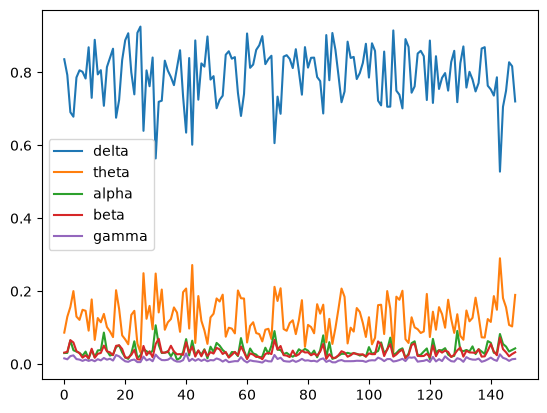

In [90]:
epoch_features.plot();

In [91]:
epoch_features["subject"] = "sub-001"

In [92]:
epoch_features["group"] = "A"

In [93]:
subject_info = participants[participants["participant_id"] == "sub-001"].iloc[0]

epoch_features["age"] = subject_info["Age"]
epoch_features["MMSE"] = subject_info["MMSE"]

In [94]:
print(epoch_features.head())

      delta     theta     alpha      beta     gamma  subject group  age  MMSE
0  0.836031  0.086330  0.030358  0.031543  0.015738  sub-001     A   57    16
1  0.792678  0.129846  0.030750  0.033570  0.013157  sub-001     A   57    16
2  0.690890  0.156520  0.065030  0.065621  0.021939  sub-001     A   57    16
3  0.678478  0.200162  0.038054  0.059418  0.023888  sub-001     A   57    16
4  0.786144  0.130374  0.034230  0.035528  0.013724  sub-001     A   57    16


In [95]:
subject_features = epoch_features[
    ["delta", "theta", "alpha", "beta", "gamma"]
].mean()

In [96]:
print(subject_features)

delta    0.793146
theta    0.126229
alpha    0.036754
beta     0.032262
gamma    0.011609
dtype: float64


In [97]:
subject_features = pd.DataFrame([subject_features])

subject_features["subject"] = "sub-001"
subject_features["group"] = "A"
subject_features["age"] = subject_info["Age"]
subject_features["MMSE"] = subject_info["MMSE"]

In [98]:
print(subject_features)

      delta     theta     alpha      beta     gamma  subject group  age  MMSE
0  0.793146  0.126229  0.036754  0.032262  0.011609  sub-001     A   57    16


In [99]:
print(subject_features.isna().sum())

delta      0
theta      0
alpha      0
beta       0
gamma      0
subject    0
group      0
age        0
MMSE       0
dtype: int64


In [100]:
raw_for_ica = raw_notched.copy()

raw_for_ica.filter(
    l_freq=1.0,
    h_freq=None
)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 1651 samples (3.302 s)



<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>

In [101]:
from mne.preprocessing import ICA

ica = ICA(
    n_components=0.99,
    method="fastica",
    rng=97,
    max_iter="auto"
)

ica.fit(raw_for_ica)

Fitting ICA to data using 19 channels (please be patient, this may take a while)
Selecting by explained variance: 8 components
Fitting ICA took 5.7s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,15 iterations on raw data (299900 samples)
ICA components,8
Available PCA components,19
Channel types,eeg
ICA components marked for exclusion,—


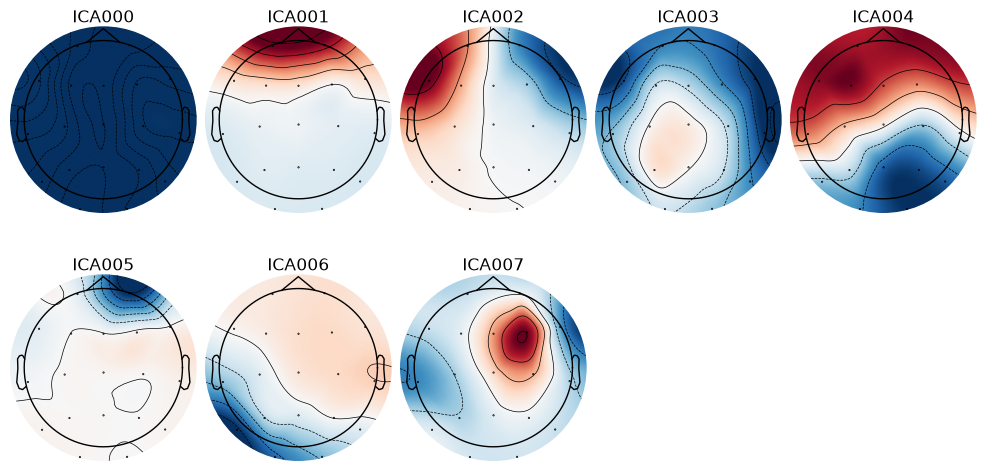

In [102]:
ica.plot_components();

Creating RawArray with float64 data, n_channels=8, n_times=299900
    Range : 0 ... 299899 =      0.000 ...   599.798 secs
Ready.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


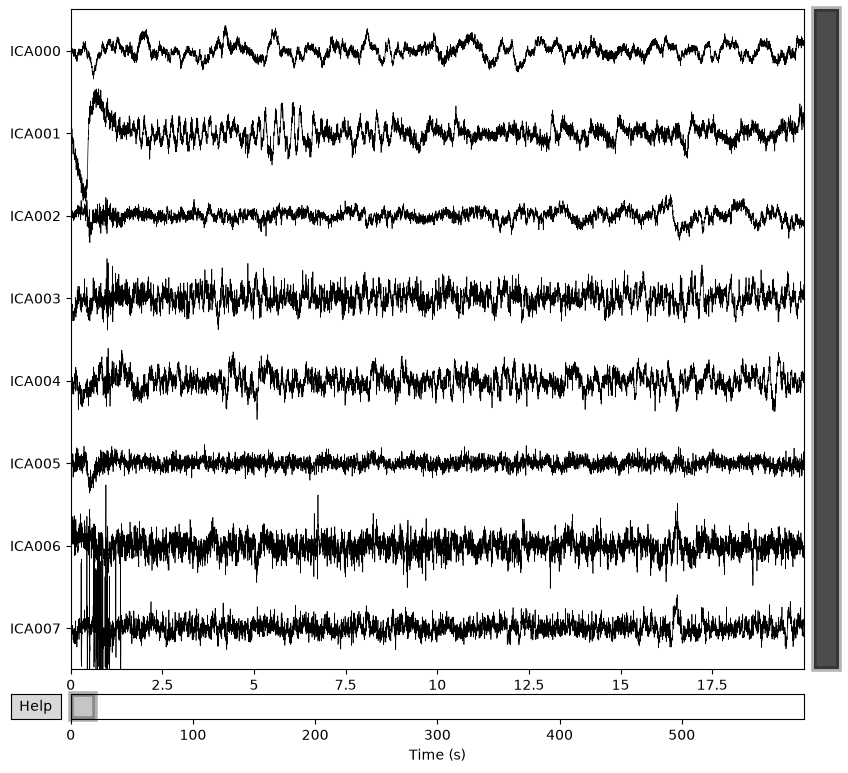

In [103]:
ica.plot_sources(raw_for_ica);

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
299 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
299 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
299 matching events found
No baseline correction applied
0 projection items activated


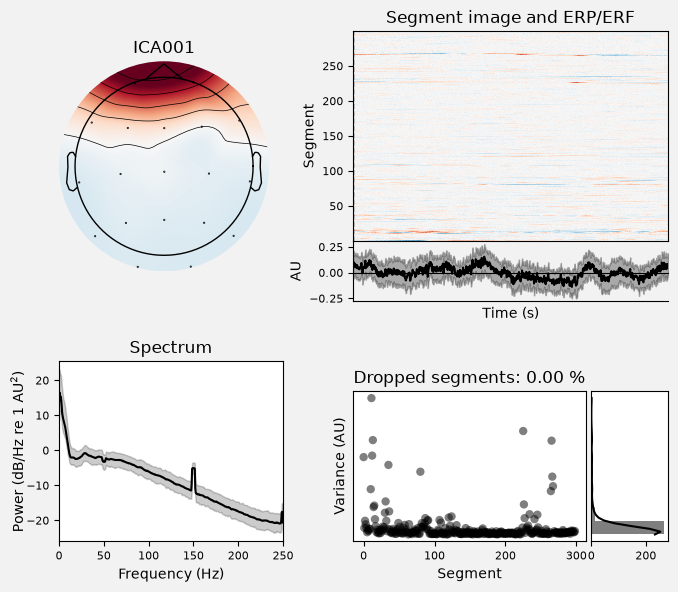

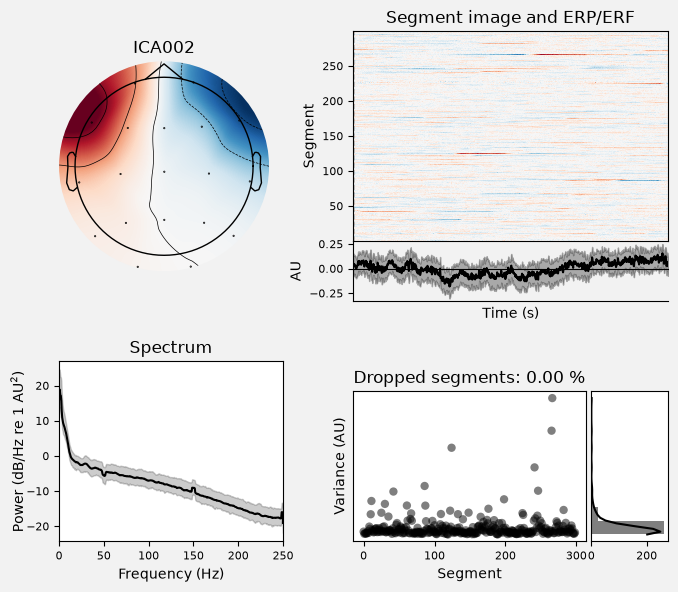

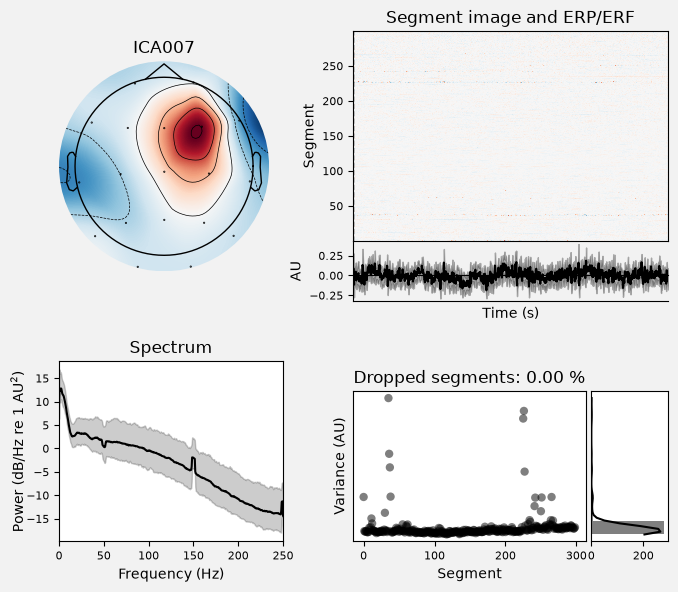

[<Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>]

In [104]:
ica.plot_properties(
    raw_for_ica,
    picks=[1, 2, 7]
)

In [105]:
raw_iclabel = raw_notched.copy()

raw_iclabel.set_eeg_reference("average")

raw_iclabel.filter(
    l_freq=1.0,
    h_freq=100.0
)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 1651 samples (3.302 s)



<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>

In [106]:
ica_iclabel = ICA(
    n_components=18,
    method="infomax",
    fit_params=dict(extended=True),
    rng=97,
    max_iter="auto"
)

ica_iclabel.fit(raw_iclabel)

Fitting ICA to data using 19 channels (please be patient, this may take a while)
Selecting by number: 18 components
Computing Extended Infomax ICA
Fitting ICA took 122.1s.


Method,infomax
Fit parameters,extended=Truemax_iter=500
Fit,500 iterations on raw data (299900 samples)
ICA components,18
Available PCA components,19
Channel types,eeg
ICA components marked for exclusion,—


In [107]:
from mne_icalabel import label_components

iclabel_labels = label_components(
    raw_iclabel,
    ica_iclabel,
    method="iclabel"
)

In [108]:
print(iclabel_labels)

{'y_pred_proba': array([0.9963979 , 0.9988411 , 0.9852952 , 0.9515386 , 0.38274366,
       0.81359595, 0.9630745 , 0.8186052 , 0.9286226 , 0.9962074 ,
       0.59794605, 0.29718754, 0.6283953 , 0.9945932 , 0.9920022 ,
       0.702454  , 0.8941432 , 0.6559181 ], dtype=float32), 'labels': ['eye blink', 'eye blink', 'brain', 'eye blink', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'muscle artifact', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain']}


    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
299 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
299 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
299 matching events found
No baseline correction applied
0 projection items activated


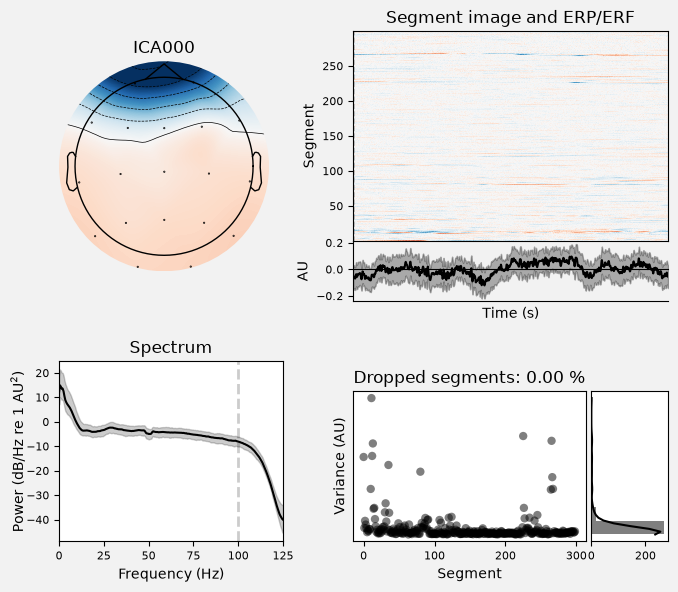

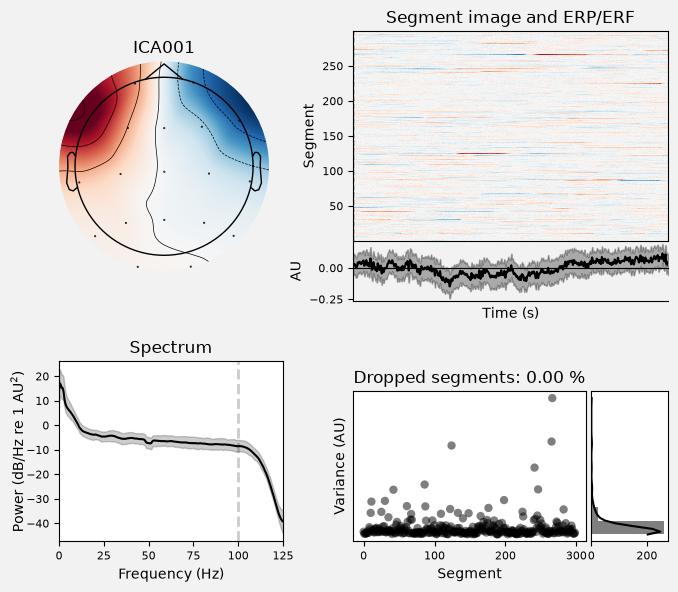

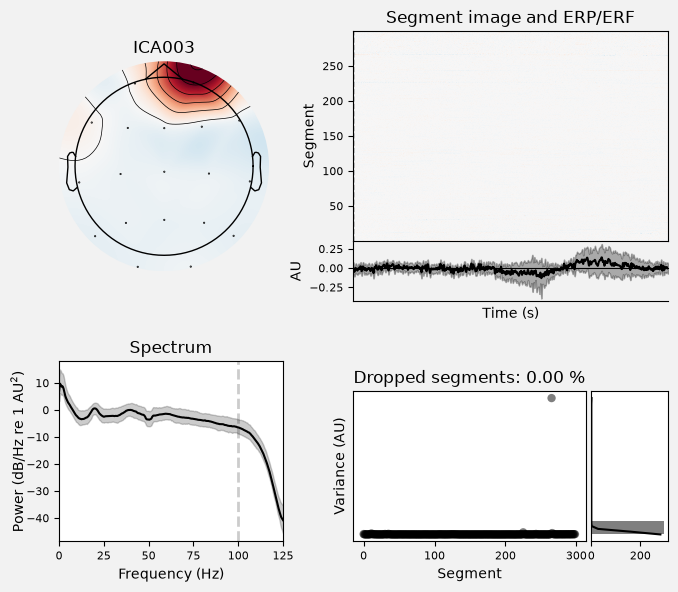

[<Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>]

In [109]:
ica_iclabel.plot_properties(
    raw_iclabel,
    picks=[0, 1, 3]
)

In [110]:
ica_iclabel.exclude = [0, 1, 3]

In [112]:
raw_clean = raw_iclabel.copy()

ica_iclabel.apply(raw_clean)

Applying ICA to Raw instance
    Transforming to ICA space (18 components)
    Zeroing out 3 ICA components
    Projecting back using 19 PCA components


<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>

In [113]:
epochs_clean = mne.make_fixed_length_epochs(
    raw_clean,
    duration=4.0,
    overlap=0,
    preload=True
)

Not setting metadata
149 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 149 events and 2000 original time points ...
0 bad epochs dropped


In [114]:
epochs_clean_psd = epochs_clean.compute_psd(
    method="welch",
    fmin=1,
    fmax=45
)

Effective window size : 4.000 (s)


In [115]:
band_power_clean = {}

psd_clean_data = epochs_clean_psd.get_data()
freqs_clean = epochs_clean_psd.freqs

for band in bands:
    fmin, fmax = bands[band]

    mask = (freqs_clean >= fmin) & (freqs_clean <= fmax)

    band_power_clean[band] = np.trapezoid(
        psd_clean_data[:, :, mask],
        x=freqs_clean[mask],
        axis=-1
    )

In [116]:
total_power_clean = np.trapezoid(
    psd_clean_data,
    x=freqs_clean,
    axis=-1
)

relative_power_clean = {}

for band in band_power_clean:
    relative_power_clean[band] = (
        band_power_clean[band] / total_power_clean
    )

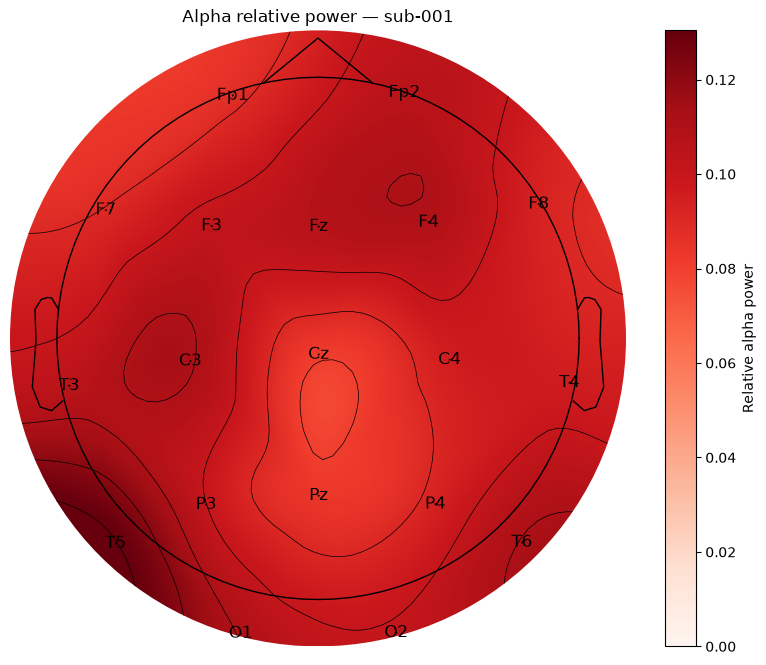

In [123]:
fig, ax = plt.subplots(figsize=(10, 8))

im, cn = mne.viz.plot_topomap(
    alpha_topomap,
    raw_clean.info,
    names=raw_clean.ch_names,
    axes=ax,
    show=False
)

for text in ax.texts:
    text.set_fontsize(12)

    ax.set_title(f"Alpha relative power — sub-001")

fig.colorbar(im, ax=ax, label="Relative alpha power")

plt.show()

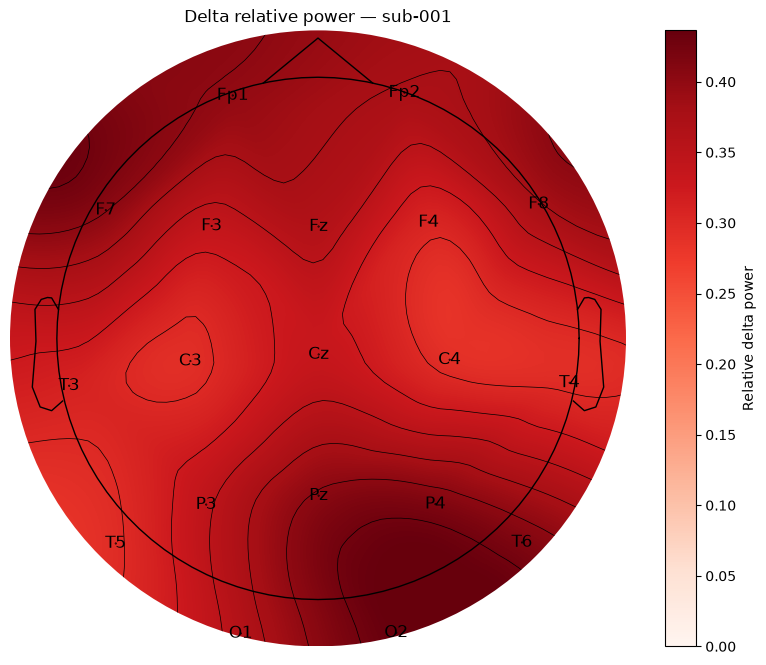

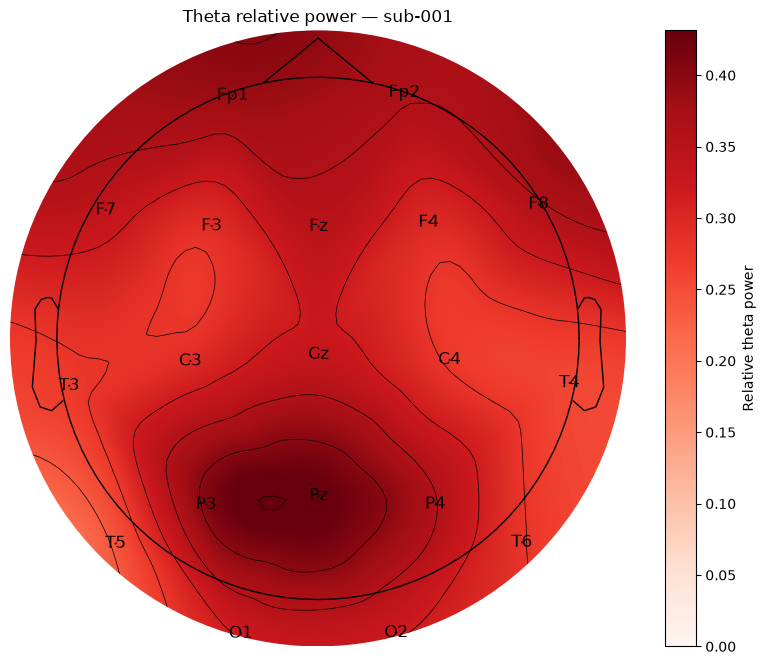

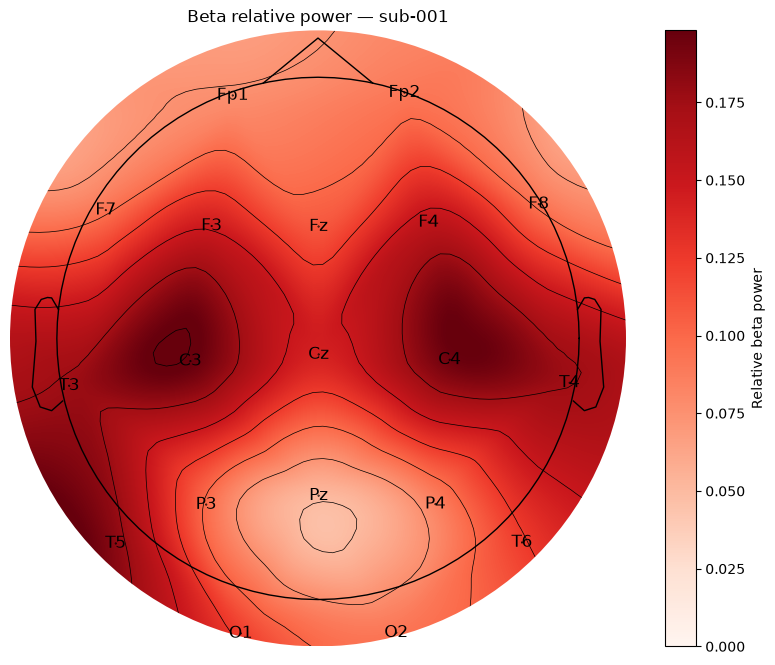

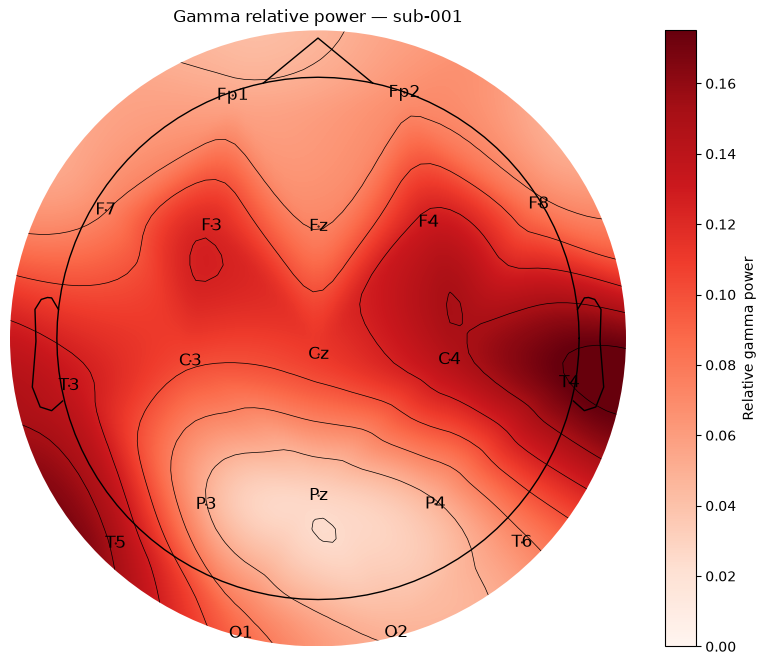

In [124]:
remaining_bands = ["delta", "theta", "beta", "gamma"]

for band in remaining_bands:
    band_topomap = relative_power_clean[band].mean(axis=0)

    fig, ax = plt.subplots(figsize=(10, 8))

    im, cn = mne.viz.plot_topomap(
        band_topomap,
        raw_clean.info,
        names=raw_clean.ch_names,
        axes=ax,
        show=False
    )

    for text in ax.texts:
        text.set_fontsize(12)

    ax.set_title(f"{band.capitalize()} relative power — sub-001")

    fig.colorbar(
        im,
        ax=ax,
        label=f"Relative {band} power"
    )

    plt.show()

In [125]:
subject_features = {}

for band in relative_power_clean:
    subject_features[band] = relative_power_clean[band].mean(axis=1).mean()

subject_features = pd.DataFrame([subject_features])

subject_features["subject"] = "sub-001"
subject_features["group"] = "A"
subject_features["age"] = subject_info["Age"]
subject_features["MMSE"] = subject_info["MMSE"]

print(subject_features)

      delta    theta     alpha     beta     gamma  subject group  age  MMSE
0  0.355006  0.32573  0.100546  0.12696  0.091758  sub-001     A   57    16


In [126]:
subject_features.to_csv(
    "../data/sub-001_pilot_features.csv",
    index=False
)

In [127]:
print(subject_features.isna().sum())

print(
    subject_features[
        ["delta", "theta", "alpha", "beta", "gamma"]
    ].sum(axis=1)
)

delta      0
theta      0
alpha      0
beta       0
gamma      0
subject    0
group      0
age        0
MMSE       0
dtype: int64
0    1.0
dtype: float64


# Pilot Analysis — Detailed Summary and Experimental Record

## 1. Purpose of the Pilot

This pilot analysis was performed using subject `sub-001` to develop, inspect, and validate the EEG preprocessing, spectral-analysis, visualization, and feature-extraction workflow before extending the pipeline to the complete dataset of 88 subjects.

The purpose of the pilot was not to draw any diagnostic or machine-learning conclusions from a single participant. Instead, it was used to establish a technically reproducible analysis workflow, examine the characteristics of the recordings, document preprocessing decisions, identify potential artifacts, and determine the structure of the features that will subsequently be extracted from all subjects.

---

## 2. Subject and Recording Characteristics

The pilot subject was:

- **Subject:** `sub-001`
- **Group:** `A` — Alzheimer's disease
- **Age:** 57 years
- **MMSE:** 16

The recording is a continuous, eyes-closed resting-state EEG.

The recording contained:

- **19 scalp EEG channels**
- **Sampling frequency:** 500 Hz
- **Recording duration:** approximately 599.8 s
- **Samples per channel:** 299,900
- **EEG placement scheme:** 10–20 system
- **EOG channels:** none
- **ECG channels:** none
- **EMG channels:** none

The 19 EEG channels were:

`Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, T6, Fz, Cz, Pz`

The dataset metadata specifies an acquisition reference of A1/A2. These reference electrodes are not included among the 19 recorded scalp EEG channels.

---

## 3. Initial EEG Inspection

The recording was first loaded as an MNE `Raw` object and inspected before subsequent preprocessing.

The complete-recording signal statistics were:

- **Minimum:** approximately `-0.000466 V`
- **Maximum:** approximately `0.002880 V`
- **Mean:** approximately `3.35 × 10⁻⁵ V`
- **Standard deviation:** approximately `1.11 × 10⁻⁴ V`

The signal was also inspected in the time domain. The continuous EEG contained substantial low-frequency variation together with larger transient and irregular deflections. Some changes appeared simultaneously across multiple channels, indicating the presence of common components and motivating explicit artifact assessment rather than assuming that the raw recording was artifact-free.

The EEG montage already contained valid channel-position information. Electrode locations were therefore inspected directly from the existing montage and subsequently used for topographic visualization.

---

## 4. Acquisition Filtering and Power-Line Interference

The dataset metadata documents:

- **Power-line frequency:** 50 Hz
- **Software filter:** approximately 0.4–50 Hz
- **Sampling frequency:** 500 Hz

The filter coefficients and exact frequency response of the original acquisition filter were not available in the MNE `Raw.info` object, so the exact acquisition filter response could not be reconstructed from the EEG file alone.

A PSD of the original recording was examined over a broader frequency range. A pronounced peak was detected at approximately **50.05 Hz**.

Because this spectral component agreed with the dataset's documented **50-Hz power-line frequency**, a 50-Hz notch filter was applied.

The effect of the notch filter was subsequently verified using PSD analysis. The sharp component around 50 Hz was strongly suppressed, producing the expected narrow reduction in spectral power around the target frequency.

The 50-Hz notch was therefore retained as a justified preprocessing step rather than an arbitrary frequency filter.

---

## 5. Investigation of the 62.5-Hz Spectral Component

A second narrow spectral component was observed at exactly **62.5 Hz**.

The peak characteristics were investigated in greater detail. The strongest frequency between 60 and 65 Hz was:

**62.5 Hz**

with an average power of approximately:

**4.11 × 10⁻¹¹ V²/Hz**

The neighboring frequency bins showed a sharply localized peak:

- 62.01 Hz → approximately `1.59 × 10⁻¹³`
- 62.26 Hz → approximately `7.67 × 10⁻¹²`
- 62.50 Hz → approximately `4.11 × 10⁻¹¹`
- 62.74 Hz → approximately `7.64 × 10⁻¹²`
- 62.99 Hz → approximately `1.46 × 10⁻¹³`

The component was also present at very similar power across all 19 electrodes, rather than being restricted to a single channel.

To determine whether the component was introduced by the 50-Hz notch, the 62.5-Hz power was compared before and after notch filtering:

- **Before notch:** `4.1136 × 10⁻¹¹ V²/Hz`
- **After notch:** `4.1118 × 10⁻¹¹ V²/Hz`

The values were essentially unchanged, indicating that the 62.5-Hz component was already present in the original recording and was not created by the 50-Hz notch.

A narrow-band time-domain visualization of the 60–65 Hz range was also performed. Because that visualization itself used a narrow band-pass filter, the resulting oscillatory appearance was not treated as sufficient evidence that the component represented a physiological EEG rhythm.

The 62.5-Hz component was therefore **not removed**. The available metadata does not establish a sufficiently defensible source for applying an additional notch at 62.5 Hz, and the main feature-extraction analysis was restricted to the 1–45 Hz range.

---

## 6. ICA-Based Artifact Assessment

ICA was explored initially using FastICA to inspect the independent-component structure of the recording. That exploratory decomposition successfully produced independent components, but it was not used for the final ICLabel-based artifact classification.

A separate ICA preparation was subsequently created for ICLabel-based classification.

For this preparation:

- The EEG was re-referenced to the common average.
- A 1–100 Hz filter was used for the ICA input.
- Extended Infomax ICA was fitted.
- 18 components were retained to account for the effective rank of the 19-channel average-referenced EEG.

The 1–100 Hz preparation was used specifically for the ICA/ICLabel input. Because the original recording already contains documented acquisition filtering, filtering the copy to 100 Hz does not restore frequencies that were already attenuated during acquisition.

---

## 7. ICLabel Classification and Component Selection

ICLabel was used to classify the resulting 18 independent components.

The highest-confidence artifact classifications relevant to the pilot were:

| Component | ICLabel classification | Probability |
|---|---|---:|
| ICA000 | Eye blink | 99.64% |
| ICA001 | Eye blink | 99.88% |
| ICA003 | Eye blink | 95.15% |

These components also showed strong frontal spatial patterns consistent with ocular activity during visual inspection.

ICA000, ICA001, and ICA003 were therefore excluded from the final ICA reconstruction.

ICA011 received a **muscle-artifact classification with approximately 29.7% probability**. Because this classification was uncertain, the component was retained rather than removed automatically.

No additional components were excluded solely on the basis of weak or uncertain classifications.

The final ICA exclusion set was therefore:

`[0, 1, 3]`

Dedicated EOG channels were unavailable in this dataset, so ocular artifact identification relied on the combination of ICA decomposition, component topography, temporal behavior, and ICLabel classification.

---

## 8. Epoching

Following ICA artifact removal, the cleaned continuous EEG was divided into fixed-length, non-overlapping epochs.

The selected epoch duration was:

**4 seconds**

At the recording sampling frequency of 500 Hz:

`4 s × 500 samples/s = 2,000 samples per epoch`

The recording produced:

- **149 epochs**
- **19 channels**
- **2,000 samples per epoch**

The resulting epoch structure was therefore:

`149 × 19 × 2,000`

Epoching was used to divide the long continuous recording into manageable analysis windows and to allow spectral features to be estimated repeatedly across the recording.

The individual epochs were not treated as independent subjects. They were subsequently aggregated to obtain a subject-level representation, which is important for avoiding subject-level data leakage in the later machine-learning stage.

---

## 9. Power Spectral Density Analysis

Welch's method was used to calculate the power spectral density for every epoch and electrode.

The PSD was calculated over:

**1–45 Hz**

The resulting PSD structure was:

`149 epochs × 19 electrodes × 177 frequency bins`

The frequency bins were spaced at **0.25 Hz**, ranging from:

`1.00 Hz → 45.00 Hz`

This representation provided the frequency-domain basis for calculating band-specific spectral features.

---

## 10. Frequency-Band Power Extraction

Five frequency bands were defined for the feature-extraction stage:

| Band | Frequency range |
|---|---:|
| Delta | 1–4 Hz |
| Theta | 4–8 Hz |
| Alpha | 8–13 Hz |
| Beta | 13–30 Hz |
| Gamma | 30–45 Hz |

For each frequency band, the PSD was numerically integrated across the corresponding frequency range using the trapezoidal integration method.

For every band, this produced:

`149 epochs × 19 electrodes`

The resulting values represent the band-specific spectral power for each epoch and electrode.

---

## 11. Relative Power

Total spectral power over the 1–45 Hz range was calculated for every epoch and electrode.

Relative power was then calculated as:

`Relative band power = band power / total 1–45 Hz power`

This produced relative-power arrays with dimensions:

`149 × 19`

for each of the five frequency bands.

Relative power was used so that the analysis describes the **distribution of spectral power across frequency bands**, rather than depending only on the absolute signal magnitude.

As a quality-control check, the five relative-power features for the final subject-level representation summed to:

**1.0**

indicating that the defined five bands accounted for the complete 1–45 Hz feature range used in this analysis.

---

## 12. Electrode Averaging and Subject-Level Representation

At the epoch level, each frequency band was represented by 19 electrode-specific relative-power values.

These values were averaged across the 19 electrodes for each epoch, producing:

`149 epochs × 5 band features`

The five features were:

- Delta relative power
- Theta relative power
- Alpha relative power
- Beta relative power
- Gamma relative power

The five epoch-level features were then averaged across the 149 epochs to obtain a single subject-level spectral representation.

Thus, the final transformation was:

`149 epochs × 19 electrodes → 149 epochs × 5 features → 1 subject × 5 features`

This subject-level representation is the structure intended for the later 88-subject machine-learning dataset.

---

## 13. Topographic Analysis

Topographic maps were generated for delta, theta, alpha, beta, and gamma relative power.

For each frequency band, the 149 epoch-level values were first averaged across time, leaving one value for each of the 19 electrodes.

The resulting 19 values were mapped to the recorded electrode positions using the EEG montage.

The topographic maps provide spatial information that is lost when the 19 electrodes are reduced to a single average value.

The pilot therefore includes both:

1. **Scalp-averaged spectral features** for subsequent machine-learning analysis.
2. **Spatial topographic visualizations** for exploratory and quality-control purposes.

---

## 14. Final Subject-Level Features — sub-001

After ICA-based artifact removal and the subsequent spectral analysis, the final subject-level relative-power features for `sub-001` were:

| Feature | Relative power |
|---|---:|
| Delta | 0.355006 |
| Theta | 0.325730 |
| Alpha | 0.100546 |
| Beta | 0.126960 |
| Gamma | 0.091758 |

The five values sum to:

**1.000000**

The final feature table contained no missing values.

The final subject-level record also retained:

- Subject ID: `sub-001`
- Diagnostic group: `A`
- Age: `57`
- MMSE: `16`

---

## 15. Major Observations From the Pilot

Several observations were important for defining the full-dataset workflow.

### Spectral observations

The recording showed substantial low-frequency spectral power. The pilot subject-level feature representation contained higher relative contributions from the lower-frequency bands than from the higher-frequency bands.

The exact values obtained from this single subject should not be interpreted as evidence of an Alzheimer's-specific spectral pattern. They describe the pilot recording only.

### Power-line interference

A distinct component near 50 Hz was clearly present and was consistent with the documented 50-Hz power-line frequency. The 50-Hz notch filter strongly reduced this component.

### 62.5-Hz component

A narrow 62.5-Hz component was observed across the channels. Its source could not be established confidently from the available metadata and it was therefore retained outside the 1–45 Hz feature range rather than being removed using an unsupported additional notch.

### Artifact structure

ICA revealed several components strongly associated with eye-blink activity. ICLabel provided high-confidence classifications for ICA000, ICA001, and ICA003, and these components were excluded before final feature extraction.

The relatively low-confidence muscle-artifact classification of ICA011 was not considered sufficient evidence for removal.

### Effect of preprocessing

The relative spectral distribution changed substantially after re-referencing and ICA-based artifact correction. This demonstrates that preprocessing decisions can materially affect extracted EEG features and therefore must remain consistent when the pipeline is applied across all subjects.

### Temporal structure

The continuous recording was successfully divided into 149 four-second windows. Epoch-level analysis allowed the spectral properties of the recording to be characterized over time before being summarized into a subject-level representation.

### Spatial structure

The five frequency bands showed distinct spatial distributions across the scalp in the topographic maps. These visualizations preserve spatial information that is not retained in the final scalp-averaged machine-learning features.

---

## 16. Limitations of the Pilot

This pilot is based on a single subject and therefore cannot be used to evaluate diagnostic differences, classification performance, or generalizability.

The dataset does not contain dedicated EOG, ECG, or EMG channels, which limits direct physiological validation of ICA component classifications.

The pilot preprocessing was designed as an MNE-based workflow and does not attempt to reproduce every detail of the dataset authors' original preprocessing pipeline. In particular, the published preprocessing procedure included additional artifact-processing steps that were not reproduced here.

The purpose of the pilot is therefore **pipeline development and validation**, not direct replication of the original preprocessing or inference about Alzheimer's disease.

---

## 17. Pilot Conclusion

The pilot established a complete workflow for converting continuous resting-state EEG into cleaned, interpretable, subject-level spectral features.

The validated workflow is:

**Continuous EEG → signal inspection → 50-Hz interference removal → ICA/ICLabel artifact handling → fixed-length epoching → Welch PSD → frequency-band power → relative power → spatial visualization → subject-level feature representation**

The pilot workflow is now considered established for the next stage.